# Анализ сходства эмбеддингов

## Идея
Эксперимент отвечает на вопрос:

**Насколько разные представления одного и того же текста эквивалентны друг другу.**

Используются 10 различных методов, сравнивающих "похожесть" наборов эмбеддингов.

## Методы

### 1. RSA (Spearman)
1. Считает все попарные расстояния внутри группы.
2. Получает вектор расстояний.
3. Сравнивает ранги расстояний между X и Y.

Что измеряет:

**Сохраняется ли структура расстояний**. 

Если близкие точки в X остаются близкими в Y и дальние остаются дальними, то RSA высокий.

### 2. RSA Kendall
Более строгая версия RSA (лучше при маленьких выборках, устойчивее к выбросам).

### 3. CKA (linear)
Сравнивает матрицы
```text
XᵀY
```

Что измеряет:

**Насколько подпространства совпадают**.

### 4. Procrustes
Ищет
```text
Y ≈ a·X·R + b
```
где:
* R — поворот
* a — масштаб
* b — сдвиг

Что измеряет:

Можно ли **наложить одно пространство на другое**.

### 5. Cosine similarity
```text
cos(x, y) = (x · y) / (||x|| ||y||)
```

Что измеряет:
**Среднюю направленность векторов**:
* 1 - одинаковые направления
* 0 - ортогональны
* -1 - противоположны

### 6. Pearson correlation
Для каждого измерения
```text
corr(X[:, i], Y[:, i])
```

Что измеряет:

**Линейную зависимость по координатам**.

### 7. Euclidean similarity
Берёт среднее расстояние
```text
||x - y||
```

Что измеряет:
**Абсолютную близость пространств**.

### 8. Manhattan similarity
```text
|x - y|
```

Более устойчив к выбросам, чем Euclidean.

### 9. kNN overlap
Для каждой точки:
* находит k соседей в X
* находит k соседей в Y
* считает пересечение

Что измеряет:

**Сохраняется ли локальная структура**.
* 1 - те же соседи
* 0 - совсем другая структура

### 10. Linear Probe
Пытается обучить:
```text
Y = f(X)
```

Что измеряет:

**Насколько одно пространство линейно предсказывает другое**.
* 1 - идеально предсказывается
* 0 - нет линейной связи

## Интерпретация

Глобальная структура:
* CKA
* Procrustes

Структура расстояний (сохраняется ли геометрия):
* RSA
* RSA Kendall

Локальная структура (те же ли соседи):
* kNN

Направления (смотрят ли векторы одинаково):
* Cosine
* Pearson

Абсолютные расстояния (насколько близко физически):
* Euclidean
* Manhattan

Предсказуемость (можно ли восстановить):
* LinearProbe

## Энкодеры
1. all-mpnet-base-v2

In [1]:
ENCODERS = [
    "all-mpnet-base-v2",
]

ENCODE_BATCH_SIZE = 32

CACHE_DIR = "../emb_cache"

DEVICE = "mps"

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import re
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import spearmanr, kendalltau
from scipy.spatial import procrustes
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
import math

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [5]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]#.sample(n=50, random_state=SEED)

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)#.sample(n=100, random_state=SEED)
df_train, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [6]:
print(f"Загружено {len(df_train)} записей Ivy Panda (живые, train)")
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 90805 записей Ivy Panda (живые, train)
Загружено 74976 записей (синтетика + живые, test)


In [7]:
def print_big_header(text, width=100):
    print("\n" + "=" * width)
    print(text.center(width))
    print("=" * width)

In [8]:
def normalize_f(data):
    data = torch.from_numpy(data).float()
    data = F.normalize(data, p=2, dim=0)
    return data.numpy()

def dwp_pooling_diag_far(X, eps=1e-8):
    mu = X.mean(axis=0)
    var = X.var(axis=0) + eps
    dists = np.sqrt(((X - mu) ** 2 / var).sum(axis=1))
    
    weights = np.exp(dists)
    weights /= weights.sum() + eps

    return weights @ X

def _compute_hash(data, model_name):
    h = hashlib.sha256()
    h.update(model_name.encode("utf-8"))

    for text in data:
        h.update(text.encode("utf-8"))

    return h.hexdigest()[:32]


def get_embeddings(model, data, model_name, cache_dir=CACHE_DIR):
    safe_model_name = model_name.replace("/", "__")
    
    os.makedirs(cache_dir, exist_ok=True)

    cache_key = _compute_hash(data, model_name)
    cache_path = os.path.join(cache_dir, f"{safe_model_name}_{cache_key}.npy")
    cache_counts_path = os.path.join(cache_dir, f"{safe_model_name}_counts_{cache_key}.npy")

    if os.path.exists(cache_path) and os.path.exists(cache_counts_path):
        print(f"Loading embeddings from cache for {model_name}...")
        all_embeddings = np.load(cache_path)
        sentence_counts = np.load(cache_counts_path)
    else:
        print(f"Computing embeddings for {model_name}...")
    
        all_sentences = []
        sentence_counts = []
        for text in tqdm(data):
            text = re.sub(r"\n+", ". ", text)
            sentences = nltk.sent_tokenize(text)
    
            if "e5" in model_name:
                sentences = [f"passage: {s}" for s in sentences]
    
            all_sentences.extend(sentences)
            sentence_counts.append(len(sentences))
    
        all_embeddings = model.encode(
            all_sentences,
            batch_size=ENCODE_BATCH_SIZE,
            normalize_embeddings=True,
            show_progress_bar=True,
            device=DEVICE,
        )

        np.save(cache_path, all_embeddings)
        np.save(cache_counts_path, sentence_counts)

    mean_vals = []
        
    max_vals = []
    var_vals = []
    med_vals = []
        
    mean_diff_vals = []
    max_diff_vals = []
    min_diff_vals = []
    med_diff_vals = []
    var_diff_vals = []
        
    dwp_vals = []
    
    idx = 0
    for count in tqdm(sentence_counts):
        embeddings = all_embeddings[idx: idx + count]

        mean_val = np.mean(embeddings, axis=0)

        max_val = np.max(embeddings, axis=0)
        var_val = np.var(embeddings, axis=0)
        med_val = np.median(embeddings, axis=0)

        diffs = embeddings[1:] - embeddings[:-1]
        min_diff_val = np.min(diffs, axis=0)
        mean_diff_val = np.mean(diffs, axis=0)
        max_diff_val = np.max(diffs, axis=0)
        med_diff_val = np.median(diffs, axis=0)
        var_diff_val = np.var(diffs, axis=0)

        dwp_val = dwp_pooling_diag_far(embeddings)

        mean_vals.append(mean_val)

        max_val = normalize_f(max_val)
        var_val = normalize_f(var_val)
        med_val = normalize_f(med_val)

        min_diff_val = normalize_f(min_diff_val)
        mean_diff_val = normalize_f(mean_diff_val)
        max_diff_val = normalize_f(max_diff_val)
        med_diff_val = normalize_f(med_diff_val)
        var_diff_val = normalize_f(var_diff_val)

        dwp_val = normalize_f(dwp_val)

        max_vals.append(max_val)
        var_vals.append(var_val)
        med_vals.append(med_val)

        min_diff_vals.append(min_diff_val)
        mean_diff_vals.append(mean_diff_val)
        max_diff_vals.append(max_diff_val)
        med_diff_vals.append(med_diff_val)
        var_diff_vals.append(var_diff_val)

        dwp_vals.append(dwp_val)

    return (
        mean_vals,
        
        max_vals,
        var_vals,
        med_vals,
        
        mean_diff_vals,
        max_diff_vals,
        min_diff_vals,
        med_diff_vals,
        var_diff_vals,
        
        dwp_vals,
    )

In [9]:
def sample_embeddings(embeddings, n_samples=1000, random_state=SEED):
    rng = np.random.default_rng(random_state)
    sampled = []
    for group in embeddings:
        if len(group) <= n_samples:
            sampled.append(group)
        else:
            indices = rng.choice(len(group), size=n_samples, replace=False)
            sampled.append([group[i] for i in indices])
    return sampled

def compute_rsa_safe(embeddings):
    emb_matrix = np.vstack(embeddings)
    std_mask = emb_matrix.std(axis=0) > 0
    if std_mask.sum() == 0:
        return np.array([np.nan])
    emb_matrix = emb_matrix[:, std_mask]
    dist_matrix = squareform(pdist(emb_matrix, metric='euclidean'))
    return dist_matrix[np.triu_indices_from(dist_matrix, k=1)]

def linear_cka(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    X -= X.mean(axis=0, keepdims=True)
    Y -= Y.mean(axis=0, keepdims=True)
    hsic = np.sum((X.T @ Y)**2)
    norm_x = np.sum((X.T @ X)**2)
    norm_y = np.sum((Y.T @ Y)**2)
    return hsic / np.sqrt(norm_x * norm_y)

def procrustes_similarity(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    _, _, disparity = procrustes(X, Y)
    return 1 - disparity

def average_cosine_similarity(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    return cosine_similarity(X, Y).diagonal().mean()

def average_pearson_correlation(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    corrs = []
    for i in range(X.shape[1]):
        std_X = X[:, i].std()
        std_Y = Y[:, i].std()
        if std_X == 0 or std_Y == 0:
            continue
        corr = np.corrcoef(X[:, i], Y[:, i])[0, 1]
        corrs.append(corr)
    return np.mean(corrs) if corrs else np.nan

def average_euclidean_similarity(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    dist = np.mean(cdist(X, Y, metric='euclidean'))
    return 1 / (1 + dist)

def average_manhattan_similarity(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)
    dist = np.mean(cdist(X, Y, metric='cityblock'))
    return 1 / (1 + dist)

def knn_overlap(X, Y, k=10):
    X = np.vstack(X)
    Y = np.vstack(Y)

    k = min(k, len(X)-1)

    nn_X = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(X)
    nn_Y = NearestNeighbors(n_neighbors=k, algorithm='auto').fit(Y)

    neighbors_X = nn_X.kneighbors(return_distance=False)
    neighbors_Y = nn_Y.kneighbors(return_distance=False)

    overlaps = [
        len(set(neighbors_X[i]).intersection(set(neighbors_Y[i]))) / k
        for i in range(len(X))
    ]
    return np.mean(overlaps)

def linear_probe_score(X, Y):
    X = np.vstack(X)
    Y = np.vstack(Y)

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3)

    model = LinearRegression().fit(X_train, Y_train)
    return model.score(X_test, Y_test)

def rsa_kendall(X, Y):
    return kendalltau(compute_rsa_safe(X), compute_rsa_safe(Y)).correlation

def plot_embedding_similarity_matrices(sampled_embeddings, metrics=None):
    if metrics is None:
        metrics = [
            'RSA', 
            'RSA_Kendall',
            'CKA', 
            'Procrustes',
            'Cosine', 
            'Pearson',
            'Euclidean', 
            'Manhattan',
            'kNN',
            'LinearProbe'
        ]

    num_groups = len(sampled_embeddings)
    similarity_matrices = {
        metric: np.zeros((num_groups, num_groups))
        for metric in metrics
    }

    for i in range(num_groups):
        for j in range(i, num_groups):
            X = sampled_embeddings[i]
            Y = sampled_embeddings[j]

            results = {}

            if 'RSA' in metrics:
                results['RSA'] = spearmanr(compute_rsa_safe(X), compute_rsa_safe(Y)).correlation

            if 'RSA_Kendall' in metrics:
                results['RSA_Kendall'] = rsa_kendall(X, Y)

            if 'CKA' in metrics:
                results['CKA'] = linear_cka(X, Y)

            if 'Procrustes' in metrics:
                results['Procrustes'] = procrustes_similarity(X, Y)

            if 'Cosine' in metrics:
                results['Cosine'] = average_cosine_similarity(X, Y)

            if 'Pearson' in metrics:
                results['Pearson'] = average_pearson_correlation(X, Y)

            if 'Euclidean' in metrics:
                results['Euclidean'] = average_euclidean_similarity(X, Y)

            if 'Manhattan' in metrics:
                results['Manhattan'] = average_manhattan_similarity(X, Y)

            if 'kNN' in metrics:
                results['kNN'] = knn_overlap(X, Y)

            if 'LinearProbe' in metrics:
                results['LinearProbe'] = linear_probe_score(X, Y)

            for metric, value in results.items():
                similarity_matrices[metric][i, j] = value
                similarity_matrices[metric][j, i] = value

    cols = 2
    rows = math.ceil(len(metrics) / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    
    axes = np.array(axes).reshape(-1)
    
    for ax, metric in zip(axes, metrics):
        sns.heatmap(
            similarity_matrices[metric],
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            ax=ax
        )
        ax.set_title(metric)
        ax.set_xlabel("Group")
        ax.set_ylabel("Group")
    
    for i in range(len(metrics), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()


                                     МОДЕЛЬ: all-mpnet-base-v2                                      


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading embeddings from cache for all-mpnet-base-v2...


100%|████████████████████████████████████████████████████████████████████| 74976/74976 [01:41<00:00, 741.48it/s]


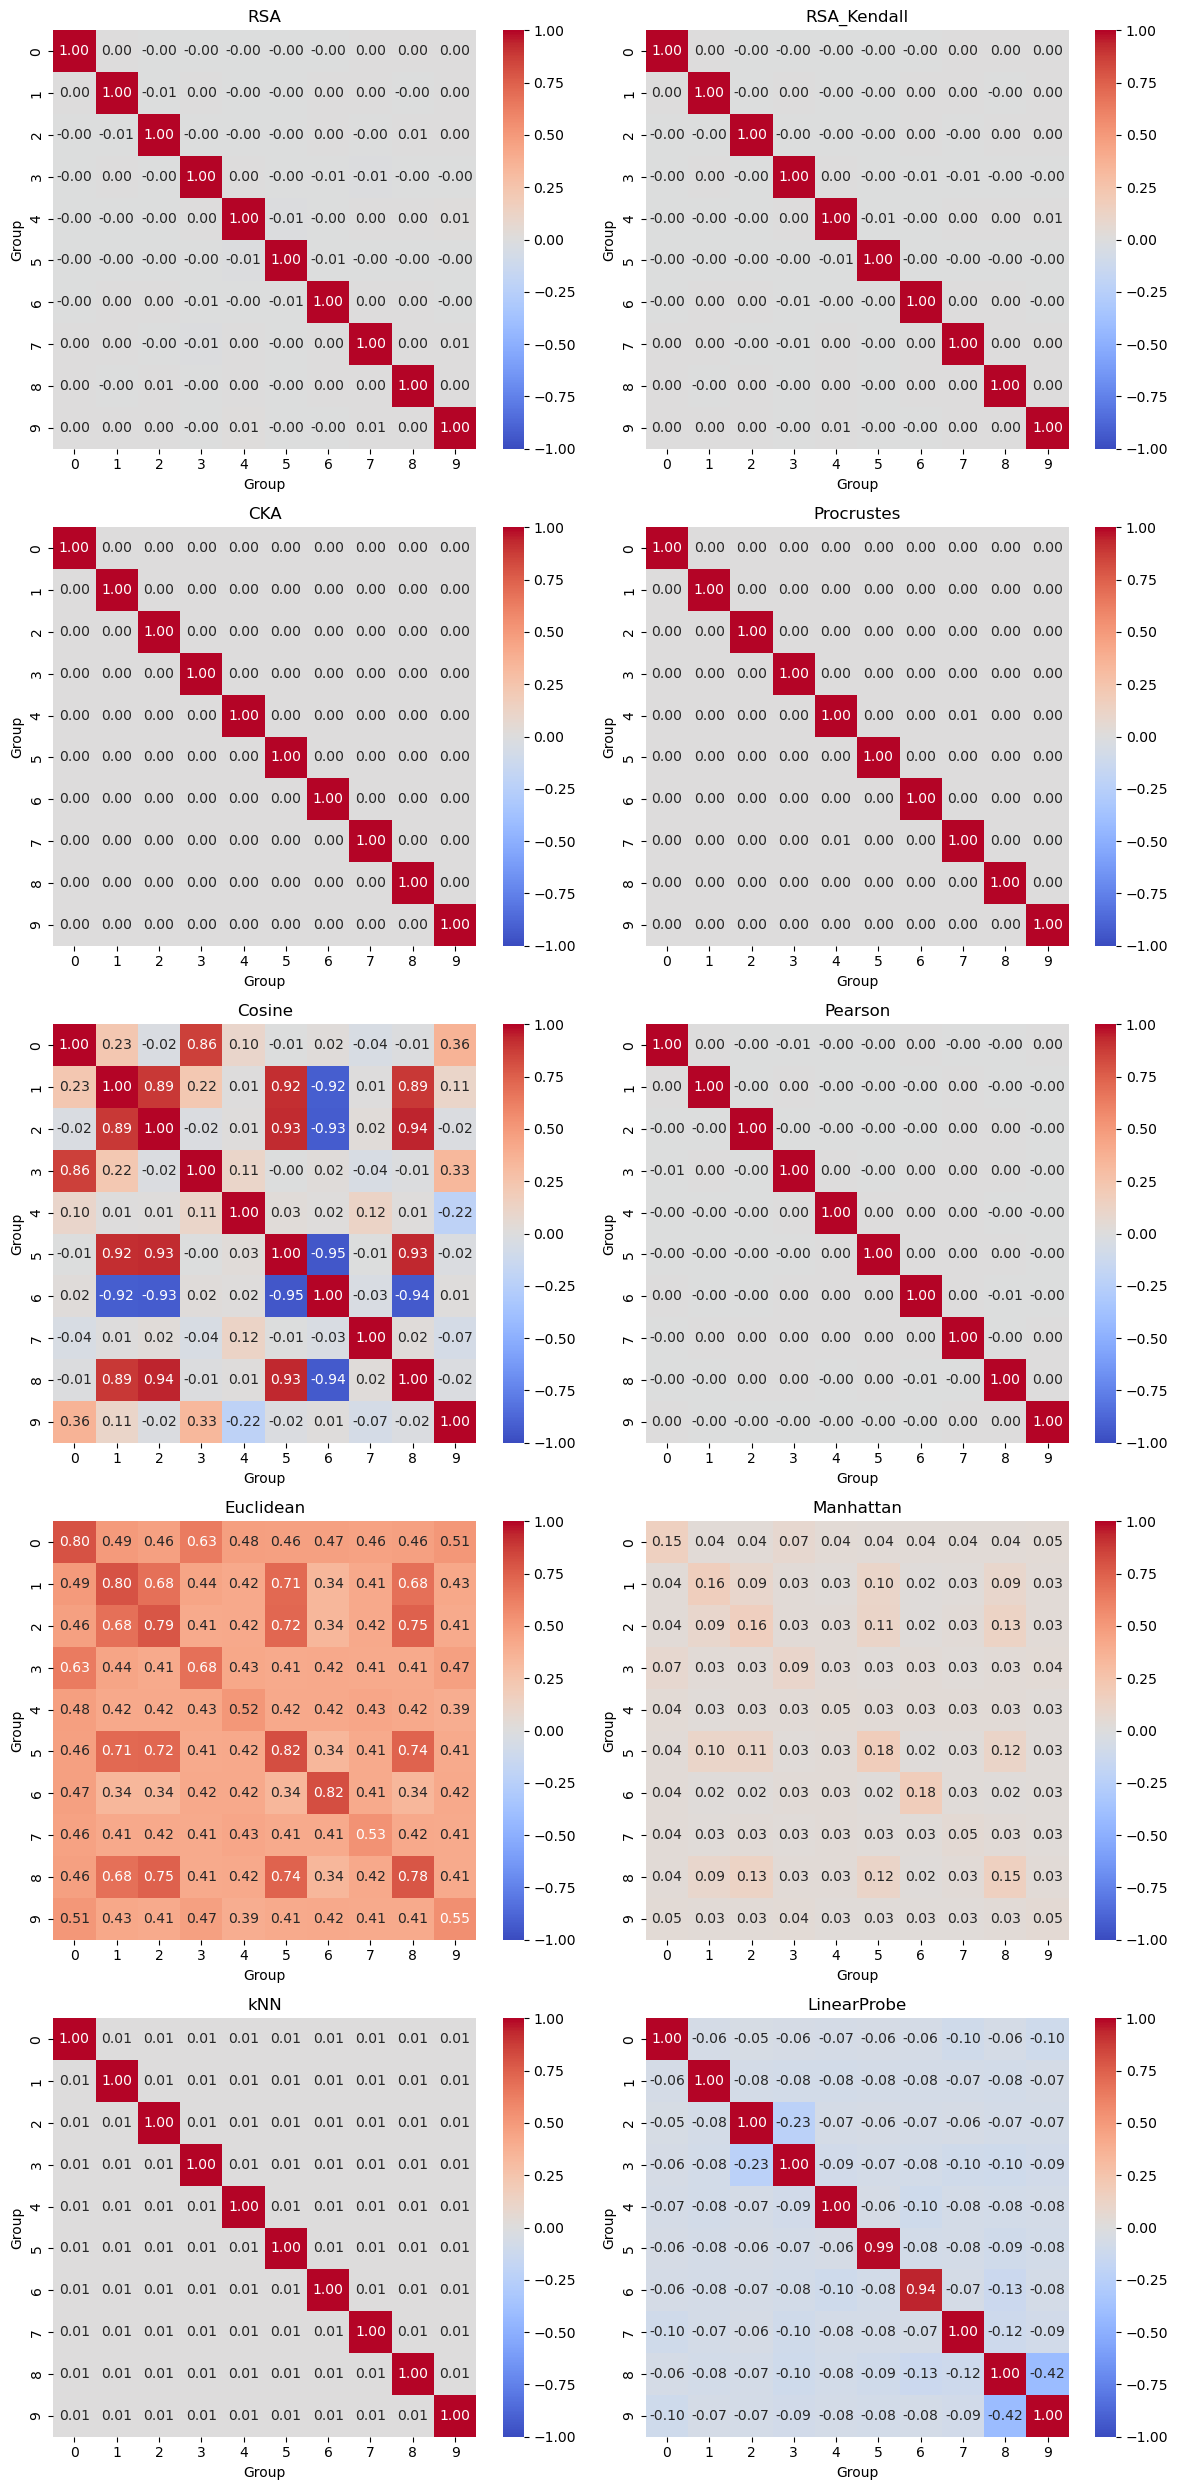

In [10]:
for model_name in ENCODERS:
    print_big_header(f"МОДЕЛЬ: {model_name}")

    model = SentenceTransformer(model_name)
    X_train = get_embeddings(model, df_all['text'].tolist(), model_name)

    sampled_train = sample_embeddings(X_train, n_samples=5000)

    plot_embedding_similarity_matrices(sampled_train)

# Вывод

## Простые пуллинги (0–3)

- Они дают почти одинаковые представления.
- Использовать их вместе почти бессмысленно - они дублируют друг друга.

## Diff poolings (4–8)

- Они кодируют не сами предложения, а изменения между ними.
- Не похожи на эмбеддинги, полученных простыми пуллингами.

Mean diff pooling и median diff pooling слабо коррелируют с другими.

## DWP (9)

Не продемонстрировал черт, отличающих его от diff poolings.

## Итог
Различия видны только в Cosine, Euclidean и Manhattan.
Следовательно:
1. Глобальная геометрия у всех эмбеддингов похожа.
2. Абсолютные расстояния отличаются.
3. Отличия именно в тех эмбеддингах, которые дают прирост метрики.